In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv('Metrics Score 2018-2025.csv')
df

,File Name,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number Of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,/Users/summer-2024/Desktop/code metrics 25/All...,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,/Users/summer-2024/Desktop/code metrics 25/All...,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,/Users/summer-2024/Desktop/code metrics 25/All...,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,/Users/summer-2024/Desktop/code metrics 25/All...,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,/Users/summer-2024/Desktop/code metrics 25/All...,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,/Users/summer-2024/Desktop/code metrics 25/All...,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1576,/Users/summer-2024/Desktop/code metrics 25/All...,1128,28.635,9.840426,29.787234,25,91,45.120000,-1,3,NaN,6,IST341,sp2025,2025
1577,/Users/summer-2024/Desktop/code metrics 25/All...,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,/Users/summer-2024/Desktop/code metrics 25/All...,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [5]:
df_tidy = df.dropna()  # NaN values are execution times that timed out by 10 sec
df_tidy = df_tidy.drop('File Name', axis=1)
df_tidy = df_tidy.rename(columns={'Number Of Functions': 'Number of Functions'})
df_tidy

,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,800,24.750,4.125000,37.250000,7,11,114.285714,3,1,1.288,7,CS35,sp2025,2025
1575,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1577,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [6]:
all_metrics = [
    'LOC', 
    'Comment Percentage', 
    'Docstring Percentage', 
    'Empty Percentage', 
    'Number of Functions', 
    'Number of Loops', 
    'CycloComplexity', 
    'Average Function Length', 
    'Max Depth', 
    'Execution Time', 
    'Weeks Covered'
]

#### Original Dataset

In [15]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)

print(y_train.value_counts())

Year
2022    335
2019    216
2018    177
2024    154
2025    131
2023    102
2021     74
2020     39
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  )
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  solver,


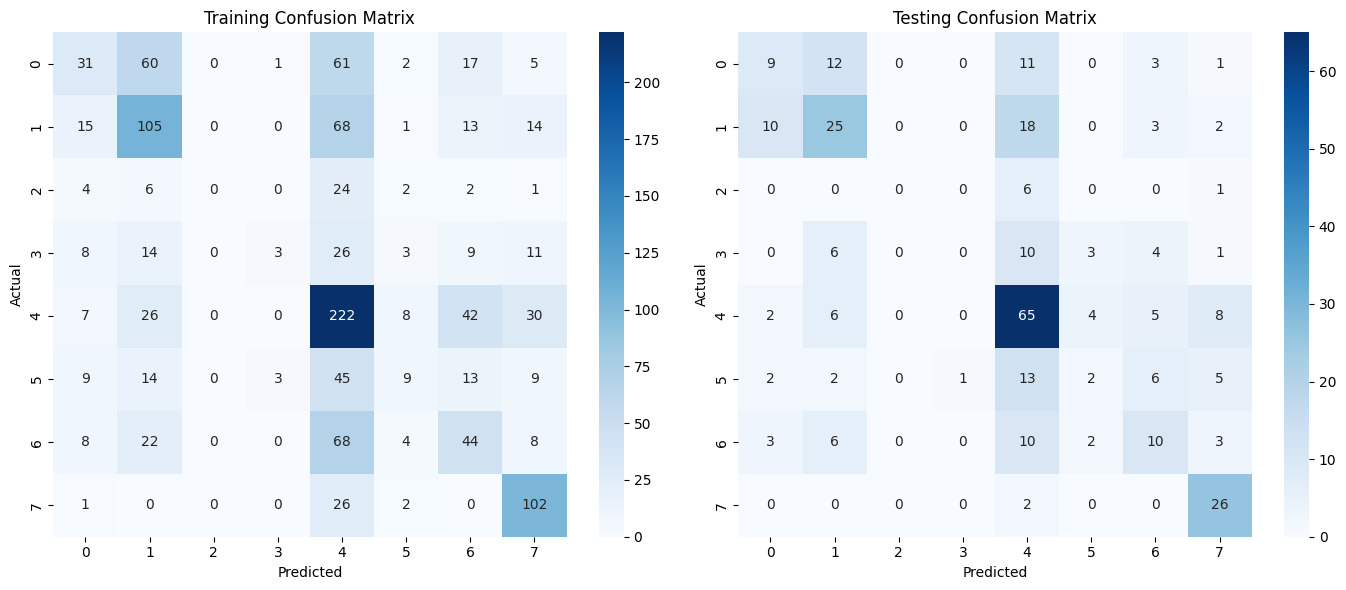

In [44]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred_original = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm_train = confusion_matrix(y_train, y_train_pred, labels=sorted(y.unique()))
sns.heatmap(cm_train, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred_original, labels=sorted(y.unique()))
sns.heatmap(cm_test, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Testing Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

#### resample Dataset

In [53]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)

avg_year = int(df_train['Year'].value_counts().mean())

resampled_list = []
for year, group in df_train.groupby('Year'):
    # upsample or downsample to average
    resampled = resample(group,
                         replace=(len(group) < avg_year),
                         n_samples=avg_year,
                         random_state=42)
    resampled_list.append(resampled)

df_resampled = pd.concat(resampled_list)

X_train_resampled = df_resampled[all_metrics]
y_train_resampled = df_resampled['Year']

print(y_train_resampled.value_counts())

Year
2018    153
2019    153
2020    153
2021    153
2022    153
2023    153
2024    153
2025    153
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  )
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  solver,


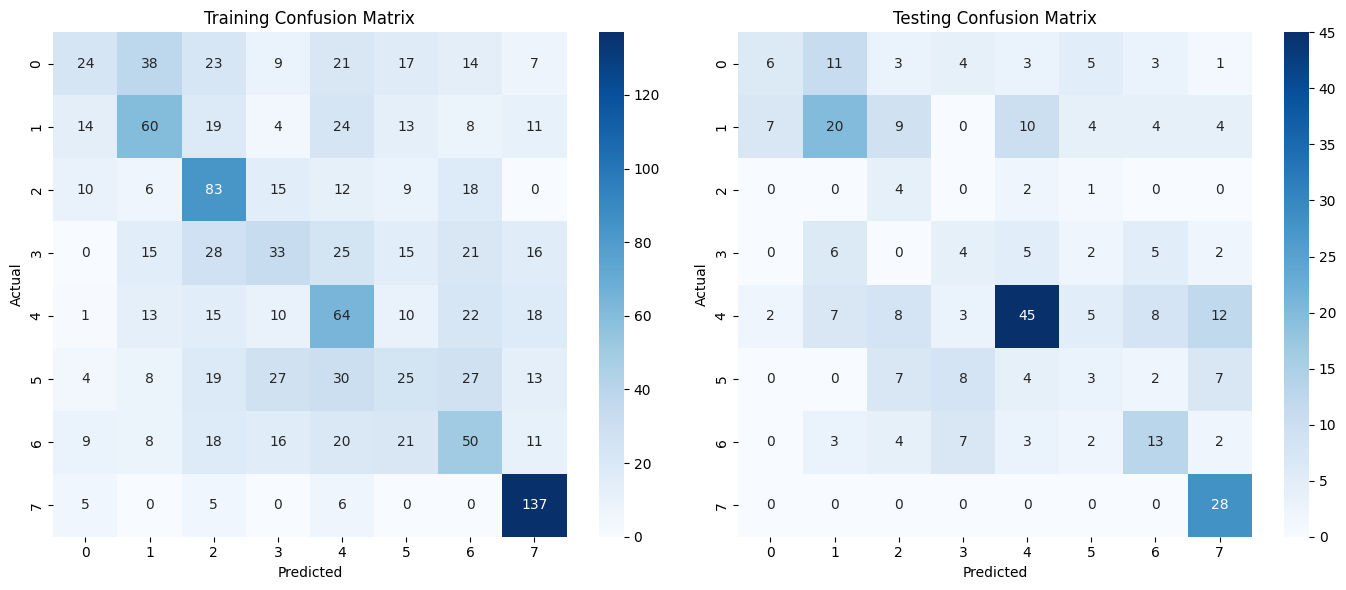

In [54]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

y_train_pred = model.predict(X_train_resampled)
y_test_pred_resampled = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm_train = confusion_matrix(y_train_resampled, y_train_pred, labels=sorted(y.unique()))
sns.heatmap(cm_train, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred_resampled, labels=sorted(y.unique()))
sns.heatmap(cm_test, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Testing Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

#### RandomOverSampler Dataset

In [39]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())

Year
2022    335
2024    335
2018    335
2025    335
2019    335
2023    335
2021    335
2020    335
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  )
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  solver,


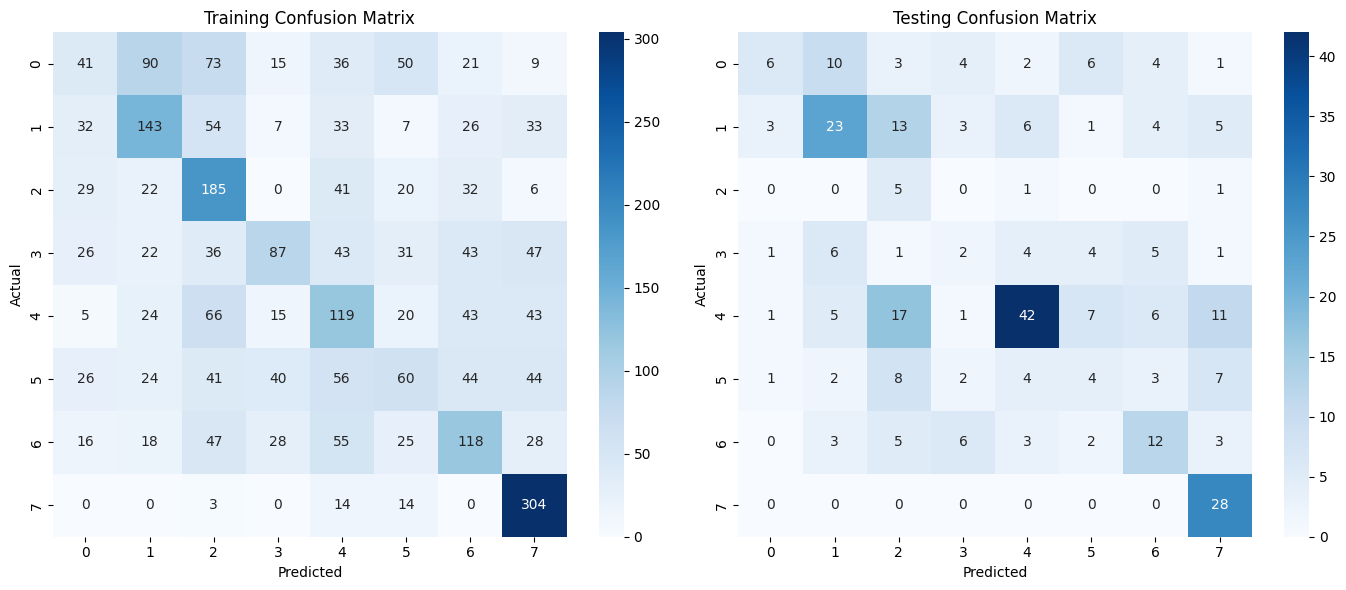

In [46]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_over, y_train_over)

y_train_pred = model.predict(X_train_over)
y_test_pred_over = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm_train = confusion_matrix(y_train_over, y_train_pred, labels=sorted(y.unique()))
sns.heatmap(cm_train, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred_over, labels=sorted(y.unique()))
sns.heatmap(cm_test, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Testing Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

#### SMOTE

In [ ]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

avg_year = int(df_train['Year'].value_counts().mean())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Year
2022    335
2024    335
2018    335
2025    335
2019    335
2023    335
2021    335
2020    335
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  )
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  solver,


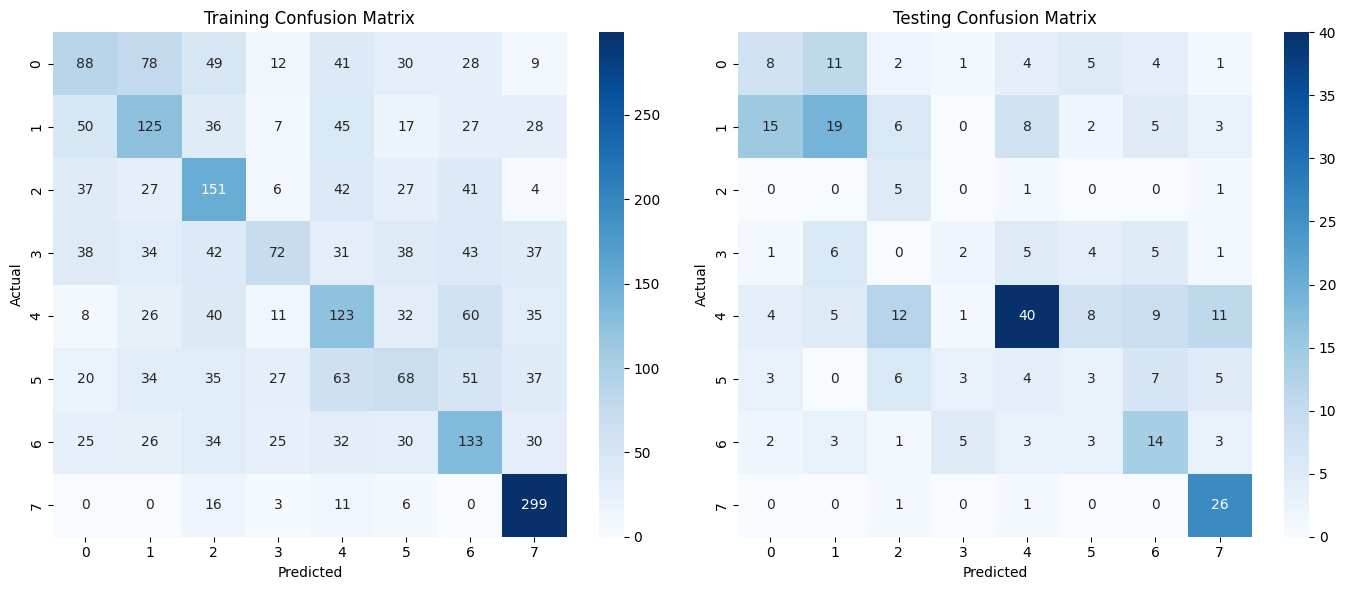

In [47]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_smote, y_train_smote)

y_train_pred = model.predict(X_train_smote)
y_test_pred_smote = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm_train = confusion_matrix(y_train_smote, y_train_pred, labels=sorted(y.unique()))
sns.heatmap(cm_train, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred_smote, labels=sorted(y.unique()))
sns.heatmap(cm_test, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Testing Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

#### Classification Report

In [56]:
print("Original Dataset:")
print(classification_report(y_test, y_test_pred_original))

print("resample Dataset:")
print(classification_report(y_test, y_test_pred_resampled))

print("RandomOverSampler Dataset:")
print(classification_report(y_test, y_test_pred_over))

print("SMOTE Dataset:")
print(classification_report(y_test, y_test_pred_smote))

Original Dataset:
              precision    recall  f1-score   support

        2018       0.35      0.25      0.29        36
        2019       0.44      0.43      0.43        58
        2020       0.00      0.00      0.00         7
        2021       0.00      0.00      0.00        24
        2022       0.48      0.72      0.58        90
        2023       0.18      0.06      0.10        31
        2024       0.32      0.29      0.31        34
        2025       0.55      0.93      0.69        28

    accuracy                           0.44       308
   macro avg       0.29      0.34      0.30       308
weighted avg       0.37      0.44      0.39       308

resample Dataset:
              precision    recall  f1-score   support

        2018       0.40      0.17      0.24        36
        2019       0.43      0.34      0.38        58
        2020       0.11      0.57      0.19         7
        2021       0.15      0.17      0.16        24
        2022       0.62      0.50      0.5

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  excluded, for example in multiclass classification to exclude a "negative
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  excluded, for example in multiclass classification to exclude a "negative
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

#### RandomOverSampler Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 3],
    'min_samples_split': [2, 3],
    'n_estimators': [175, 200, 225]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_over, y_train_over)

best_rf = grid_search.best_estimator_
print(f'Best hyperparameters: {grid_search.best_params_}')
# Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersi

Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


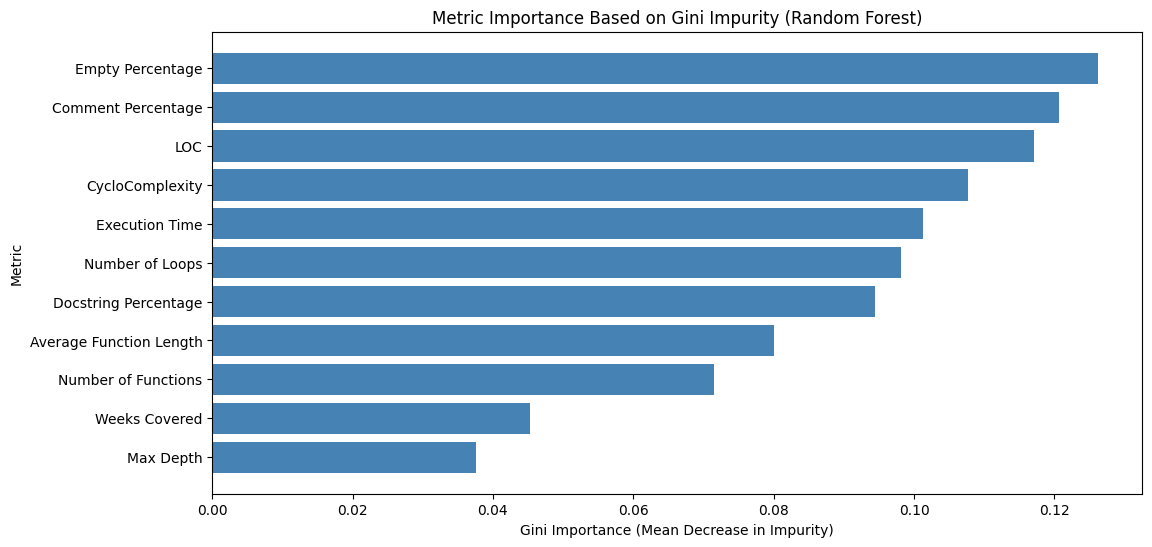

In [60]:
gini_importance = best_rf.feature_importances_

sorted_index = np.argsort(gini_importance)

plt.figure(figsize=(12, 6))
plt.barh(np.array(all_metrics)[sorted_index], np.array(gini_importance)[sorted_index], color='steelblue')
plt.xlabel('Gini Importance (Mean Decrease in Impurity)')
plt.ylabel('Metric')
plt.title('Metric Importance Based on Gini Impurity (Random Forest)')
plt.show()